# 🛡️ Compliance Prediction Pipeline
## Scenario 3 — Which Markets Are Likely to Move from Low → Moderate or Moderate → High Risk Next Quarter?

---
**Pipeline:** `Business Objective` → `Data Access` → `Data Quality` → `Root Cause Extraction` → `EDA` → `Preprocess` → `Feature Engineering` → `Model` → `Eval` → `Deploy`

---
> **Design Decisions:**
> - **Data** = Real audit file + Synthetic dataset concatenated — ensures sufficient escalation events for model training
> - **Root Cause** = Rule-based (4 labels): Tool Gap, Process Gap, Policy Gap, Execution Gap
> - **Enforcement Risk Score** = Weighted composite: Execution(40%) + Tool Gap(25%) + EOL(20%) + Process Spread(15%)
> - **Escalation Label** = Low→Moderate or Moderate→High next quarter (shift-based, zero leakage)
> - **Features** = 5 current-quarter features — direct, interpretable, no lag needed with sufficient data
> - **Model** = Random Forest (300 trees, class_weight=balanced) with Stratified 80/20 split


---
## 📌 STAGE 1 — Business Objective

| Item | Detail |
|---|---|
| **Problem Statement** | Predict which markets will move from Low → Moderate or Moderate → High risk in 2026 Q2 |
| **Target Variable** | `Escalation_Flag = 1` if Risk Level increases next quarter, else `0` |
| **Approach** | Market × Quarter level classification using current-quarter Enforcement Risk Score features |
| **Data** | Real audit observations + Synthetic dataset (concatenated) |
| **Split Strategy** | Stratified 80/20 train/test |
| **Success Metrics** | F1 ≥ 0.50, ROC-AUC ≥ 0.70 |

### Enforcement Risk Score Formula

| Component | Weight | Derived From |
|---|---|---|
| `Execution_Count` | **40%** | Count of "Gap" root causes per Market × FQ |
| `Tool_Gap_Count` | **25%** | Observations with manual/spreadsheet/no tool keywords |
| `EOL_Count` | **20%** | Observations with eol/end of life keywords |
| `Process_Spread` | **15%** | Unique processes per Market × FQ |

### Risk Level Thresholds

| Score | Risk Level |
|---|---|
| < 0.30 | Low |
| 0.30 – 0.60 | Moderate |
| > 0.60 | High |


---
## 📂 STAGE 2 — Data Access
Load real audit file and synthetic dataset, concatenate for sufficient training volume.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ══ STAGE 2: DATA ACCESS ════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df1 = pd.read_excel(
    "/content/drive/MyDrive/Prediction_Actual_DataFrame/Observation List New.xlsx",
    engine="openpyxl"
)



df = pd.concat([df1], ignore_index=True)

ALL_QS   = sorted(df['FQ'].dropna().unique().tolist())
VALID_QS = [q for q in ALL_QS if str(q).startswith('202')]

print(f'✅ Real dataset     : {len(df1):,} rows')

print(f'✅ Combined total   : {len(df):,} rows × {df.shape[1]} columns')
print(f'   FQ Range         : {VALID_QS}')
df.head()


✅ Real dataset     : 3,251 rows
✅ Combined total   : 3,251 rows × 15 columns
   FQ Range         : ['2024 Q1', '2024 Q2', '2024 Q3', '2024 Q4', '2025 Q1', '2025 Q2', '2025 Q3', '2025 Q4', '2026 Q1']


,Group,Market,Country,FQ,Review Name,Account,Platform,Process,Domain Area,Domain Area Specifics,Obs Status,Observation,Review Status,Category,InspectionTeam
0,Japan,Japan,Japan,2026 Q1,Consulting Session for Orico account (SYSOP co...,Orico,NaN,Account Governance,Other,Other,Completed,The services provided by Kyndryl were not accu...,Completed,Delivery,Japan Inspections Team
1,Japan,Japan,Japan,2026 Q1,Consulting Session for Orico account (SYSOP co...,Orico,Multiple Platforms,Account Governance,Policy Management,Policy Inaccuracy,Completed,Scope for antivirus software were not clearly ...,Completed,Delivery,Japan Inspections Team
2,SMG,ALPS,ALPS,2026 Q1,Mayr-Melnhof TTCR,Mayr-Melnhof,Linux,Account Governance,Other,Other,Deemed Accepted,"For Unix environment, 2024 Initial HC remed...",Completed,Delivery,EU Inspections Team
3,SMG,ALPS,ALPS,2026 Q1,Mayr-Melnhof TTCR,Mayr-Melnhof,Multiple Platforms,Account Governance,Other,Other,Deemed Accepted,"Per Risk RK0021114 opened for ""Healthcheck rem...",Completed,Delivery,EU Inspections Team
4,SMG,ALPS,CHAT,2026 Q1,CHAT Portfolio Inspection,Swiss Re,Multiple Platforms,Account Governance,Other,Other,Deemed Accepted,"\n\nFeb 2025 ""Exception-Both-E U-C HAT-SwissR...",Completed,Delivery,EU Inspections Team


---
## 🔍 STAGE 3 — Data Quality
Check nulls, duplicates, and key column coverage across combined dataset.


In [3]:
# ══ STAGE 3: DATA QUALITY ════════════════════════════════════════════════════════
print('━' * 58)
print('3.1  NULL CHECK')
print('━' * 58)
null_pct = (df.isnull().mean() * 100).round(2)
null_cnt = df.isnull().sum()
q_df     = pd.DataFrame({'Nulls': null_cnt, 'Null%': null_pct})
q_df     = q_df[q_df['Nulls'] > 0].sort_values('Null%', ascending=False)
print(q_df.to_string() if len(q_df) > 0 else '   No nulls found.')

print('\n' + '━' * 58)
print('3.2  DUPLICATE CHECK')
print('━' * 58)
print(f'   Duplicate rows : {df.duplicated().sum()}')

print('\n' + '━' * 58)
print('3.3  KEY COLUMN COVERAGE')
print('━' * 58)
for col in ['Market', 'FQ', 'Process', 'Account', 'Observation']:
    nn  = df[col].notna().sum()
    pct = nn / len(df) * 100
    print(f'   {"✅" if pct==100 else "⚠️ "} {col:<25} {nn:>6,} / {len(df):,} ({pct:.1f}%)')

df['Observation'] = df['Observation'].fillna('')
df['Process']     = df['Process'].fillna('Unknown')
df['Account']     = df['Account'].fillna('Unknown')
print('\n✅ Data quality checks complete.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.1  NULL CHECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                       Nulls  Null%
Platform                1971  60.63
InspectionTeam          1292  39.74
Review Name              583  17.93
Domain Area Specifics      1   0.03

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.2  DUPLICATE CHECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Duplicate rows : 54

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.3  KEY COLUMN COVERAGE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   ✅ Market                     3,251 / 3,251 (100.0%)
   ✅ FQ                         3,251 / 3,251 (100.0%)
   ✅ Process                    3,251 / 3,251 (100.0%)
   ✅ Account                    3,251 / 3,251 (100.0%)
   ✅ Observation                3,251 / 3,251 (100.0%)

✅ Data quality checks complete.



---
## 🧠 STAGE 3.5 — Root Cause Extraction

Derive `Final_Cluster` from `Observation` text using rule-based classification (4 labels):

| Keyword Match | Root Cause Label |
|---|---|
| "manual" | Tool Gap |
| "not followed" | Process Gap |
| "policy" | Policy Gap |
| *(default)* | Execution Gap |


In [6]:
# ============================================================
# USE CASE 5 – COMPLETE END-TO-END PIPELINE (ADVANCED)
# ============================================================

import pandas as pd
import numpy as np
import re
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score
)


# ============================================================
# 2️⃣ MANUAL ROOT CAUSE CLASSIFICATION
# ============================================================

def classify_root_cause(text):
    text = str(text).lower()

    education_keywords = [
        "not aware","lack of awareness","training not provided",
        "training required","user unaware",
        "misunderstood","incorrectly followed"
    ]
    if any(word in text for word in education_keywords):
        return "Education Gap"

    if "policy" in text and ("not defined" in text or "missing" in text or "outdated" in text):
        return "Policy Gap"

    if "not followed" in text or "not performed" in text or "not documented" in text:
        return "Process Gap"

    tool_keywords = [
        "manual","spreadsheet","no tool",
        "no automation","tool not available","no system"
    ]
    if any(word in text for word in tool_keywords):
        return "Tool Gap"

    if "design" in text or "control not effective" in text:
        return "Design Gap"

    if "recurring" in text or "repeated" in text:
        return "Systemic Risk"

    return "Execution Gap"

df["Root_Cause_Type"] = df["Observation"].apply(classify_root_cause)

# ============================================================
# 3️⃣ SECURITY SUB-CLUSTERING (KMEANS)
# ============================================================

sec_exec_df = df[
    (df["Process"] == "Security Management") &
    (df["Root_Cause_Type"] == "Execution Gap")
].copy()

if len(sec_exec_df) > 50:

    vectorizer_sec = TfidfVectorizer(
        max_features=2000,
        ngram_range=(1,2),
        min_df=3,
        stop_words="english"
    )

    X_sec = vectorizer_sec.fit_transform(sec_exec_df["Observation"])

    kmeans_sec = KMeans(n_clusters=5, random_state=42)
    sec_exec_df["Sec_Exec_Subcluster"] = kmeans_sec.fit_predict(X_sec)

    sec_exec_map = {
        0: "Security Review Not Performed",
        1: "Firewall Rule Governance Gap",
        2: "Logging & Retention Gap",
        3: "Excessive Privilege Enforcement Gap",
        4: "Malware Defense Control Gap"
    }

    sec_exec_df["Execution_Sub_Root_Cause"] = \
        sec_exec_df["Sec_Exec_Subcluster"].map(sec_exec_map)

    df.loc[sec_exec_df.index, "Root_Cause_Type"] = \
        sec_exec_df["Execution_Sub_Root_Cause"]


# ============================================================
# 4️⃣ FINAL CLUSTER
# ============================================================

df["Final_Cluster"] = df["Root_Cause_Type"]

print("\nFinal Cluster Distribution:")
print(df["Final_Cluster"].value_counts())



Final Cluster Distribution:
Final_Cluster
Execution Gap                          2118
Malware Defense Control Gap             319
Security Review Not Performed           247
Logging & Retention Gap                 142
Excessive Privilege Enforcement Gap     127
Firewall Rule Governance Gap            104
Process Gap                              89
Tool Gap                                 87
Design Gap                                7
Education Gap                             6
Systemic Risk                             3
Policy Gap                                2
Name: count, dtype: int64


---
## 📊 STAGE 4 — Exploratory Data Analysis

Four charts: observations per quarter, risk score distribution, escalation label balance, and Market × Quarter heatmap.


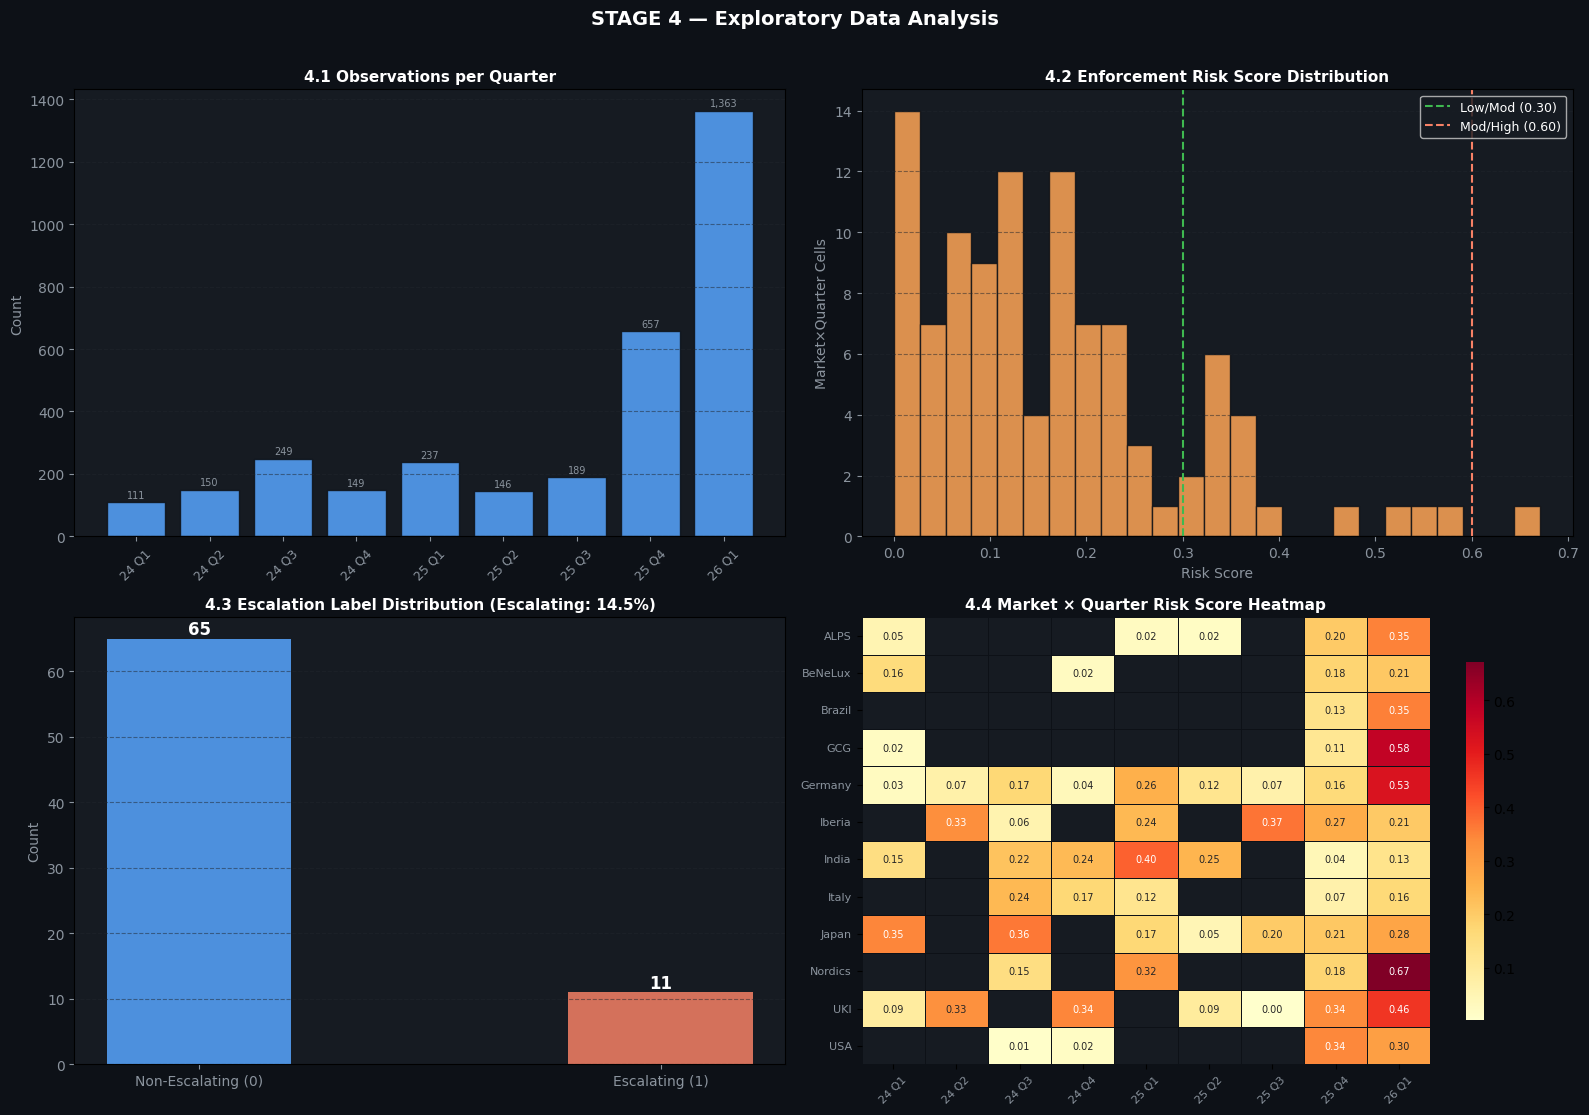

✅ EDA complete.


In [7]:
# ══ STAGE 4: EDA ════════════════════════════════════════════════════════════════
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# ── Pre-compute for EDA ───────────────────────────────────────────────────────
df['Tool_Gap_Flag'] = df['Observation'].str.contains(
    'manual|spreadsheet|no tool|no automation', case=False, na=False).astype(int)
df['EOL_Flag'] = df['Observation'].str.contains(
    'eol|end of life', case=False, na=False).astype(int)

mq_eda = df.groupby(['Market','FQ']).agg({
    'Final_Cluster'  : lambda x: x.str.contains('Gap').sum(),
    'Tool_Gap_Flag'  : 'sum',
    'EOL_Flag'       : 'sum',
    'Process'        : 'nunique',
    'Account'        : 'nunique'
}).reset_index()
mq_eda.columns = ['Market','FQ','Execution_Count','Tool_Gap_Count','EOL_Count','Process_Spread','Account_Count']

sc_eda = MinMaxScaler()
mq_eda[['Execution_Count','Tool_Gap_Count','EOL_Count','Process_Spread']] = sc_eda.fit_transform(
    mq_eda[['Execution_Count','Tool_Gap_Count','EOL_Count','Process_Spread']])

mq_eda['Enforcement_Risk_Score'] = (
    0.40*mq_eda['Execution_Count'] + 0.25*mq_eda['Tool_Gap_Count'] +
    0.20*mq_eda['EOL_Count']       + 0.15*mq_eda['Process_Spread'])
mq_eda['Risk_Level'] = mq_eda['Enforcement_Risk_Score'].apply(
    lambda s: 'Low' if s < 0.30 else ('Moderate' if s < 0.60 else 'High'))
mq_eda = mq_eda.sort_values(['Market','FQ'])
mq_eda['Next_Risk_Level'] = mq_eda.groupby('Market')['Risk_Level'].shift(-1)
mq_eda['Escalation_Flag'] = mq_eda.apply(
    lambda r: (1 if (r['Risk_Level']=='Low'      and r['Next_Risk_Level']=='Moderate') or
                    (r['Risk_Level']=='Moderate'  and r['Next_Risk_Level']=='High') else 0)
              if not pd.isna(r['Next_Risk_Level']) else np.nan, axis=1)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor='#0d1117')
for ax in axes.flat: ax.set_facecolor('#161b22')

# 4.1 Observations per Quarter
obs_q = df.groupby('FQ').size().reindex(VALID_QS, fill_value=0)
axes[0,0].bar(range(len(VALID_QS)), obs_q.values, color='#58a6ff', alpha=0.85, edgecolor='#0d1117')
for i, v in enumerate(obs_q.values):
    axes[0,0].text(i, v+max(obs_q)*0.01, f'{v:,}', ha='center', color='#8b949e', fontsize=7)
axes[0,0].set_xticks(range(len(VALID_QS)))
axes[0,0].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45, color='#8b949e', fontsize=9)
axes[0,0].set_title('4.1 Observations per Quarter', color='white', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Count', color='#8b949e')
axes[0,0].tick_params(colors='#8b949e')
axes[0,0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# 4.2 Enforcement Risk Score Distribution
axes[0,1].hist(mq_eda['Enforcement_Risk_Score'], bins=25, color='#ffa657', alpha=0.85, edgecolor='#0d1117')
axes[0,1].axvline(0.30, color='#3fb950', linestyle='--', linewidth=1.5, label='Low/Mod (0.30)')
axes[0,1].axvline(0.60, color='#f78166', linestyle='--', linewidth=1.5, label='Mod/High (0.60)')
axes[0,1].set_title('4.2 Enforcement Risk Score Distribution', color='white', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Risk Score', color='#8b949e')
axes[0,1].set_ylabel('Market×Quarter Cells', color='#8b949e')
axes[0,1].tick_params(colors='#8b949e')
axes[0,1].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[0,1].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# 4.3 Escalation Label Distribution
esc_c = mq_eda.dropna(subset=['Escalation_Flag'])['Escalation_Flag'].value_counts().sort_index()
bars  = axes[1,0].bar(['Non-Escalating (0)','Escalating (1)'], esc_c.values,
                       color=['#58a6ff','#f78166'], alpha=0.85, width=0.4)
for bar, v in zip(bars, esc_c.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, v+max(esc_c)*0.01, str(v),
                   ha='center', color='white', fontsize=12, fontweight='bold')
esc_pct = esc_c.get(1,0)/len(mq_eda.dropna(subset=['Escalation_Flag']))*100
axes[1,0].set_title(f'4.3 Escalation Label Distribution (Escalating: {esc_pct:.1f}%)',
                    color='white', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('Count', color='#8b949e')
axes[1,0].tick_params(colors='#8b949e')
axes[1,0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# 4.4 Market × Quarter Heatmap
top_mkts   = df['Market'].value_counts().head(12).index
risk_pivot = mq_eda[mq_eda['Market'].isin(top_mkts)].pivot_table(
    index='Market', columns='FQ', values='Enforcement_Risk_Score', aggfunc='mean'
).reindex(columns=VALID_QS, fill_value=0)
sns.heatmap(risk_pivot, ax=axes[1,1], cmap='YlOrRd', linewidths=0.5,
            linecolor='#0d1117', annot=True, fmt='.2f', annot_kws={'size':7},
            cbar_kws={'shrink':0.8})
axes[1,1].set_title('4.4 Market × Quarter Risk Score Heatmap', color='white', fontsize=11, fontweight='bold')
axes[1,1].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45, color='#8b949e', fontsize=8)
axes[1,1].set_yticklabels(axes[1,1].get_yticklabels(), color='#8b949e', fontsize=8)
axes[1,1].set_xlabel(''); axes[1,1].set_ylabel('')

plt.suptitle('STAGE 4 — Exploratory Data Analysis', color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('✅ EDA complete.')


---
## ⚙️ STAGE 5 — Preprocess

Build `market_q` with Enforcement Risk Score + Escalation Label. Stratified 80/20 split.


In [46]:
# ── 5.5 Risk Level — Percentile-Based Thresholds ──────────────────────────────
LOW_THRESH  = market_q['Enforcement_Risk_Score'].quantile(0.50)
HIGH_THRESH = market_q['Enforcement_Risk_Score'].quantile(0.80)
print(f'   Low/Moderate boundary (P50) : {LOW_THRESH:.4f}')
print(f'   Moderate/High boundary (P80): {HIGH_THRESH:.4f}')

market_q['Risk_Level'] = market_q['Enforcement_Risk_Score'].apply(
    lambda s: 'Low' if s < LOW_THRESH else ('Moderate' if s < HIGH_THRESH else 'High'))

# ── 5.6 Lag Features ──────────────────────────────────────────────────────────
market_q = market_q.sort_values(['Market','FQ']).reset_index(drop=True)
market_q['lag1_score']  = market_q.groupby('Market')['Enforcement_Risk_Score'].shift(1)
market_q['trend_score'] = market_q['Enforcement_Risk_Score'] - market_q['lag1_score']

# ── 5.7 Escalation Label ──────────────────────────────────────────────────────
market_q['Next_Risk_Level'] = market_q.groupby('Market')['Risk_Level'].shift(-1)

def escalation(row):
    order = {'Low': 0, 'Moderate': 1, 'High': 2}
    if pd.isna(row['Next_Risk_Level']): return 0
    return 1 if order.get(row['Next_Risk_Level'], 0) > order.get(row['Risk_Level'], 0) else 0

market_q['Escalation_Flag'] = market_q.apply(escalation, axis=1)

# ── 5.8 Training DataFrame ────────────────────────────────────────────────────
train_df = market_q.dropna(subset=['Next_Risk_Level', 'lag1_score']).copy()

print('\n' + '━' * 58)
print('5.5  RISK LEVEL DISTRIBUTION')
print('━' * 58)
for lvl in ['Low', 'Moderate', 'High']:
    cnt = (market_q['Risk_Level'] == lvl).sum()
    print(f'   {lvl:<12} : {cnt:>5,} ({cnt/len(market_q)*100:.1f}%)')

print('\n' + '━' * 58)
print('5.7  ESCALATION LABEL DISTRIBUTION')
print('━' * 58)
esc_cnt = int(train_df['Escalation_Flag'].sum())
non_cnt = int((train_df['Escalation_Flag'] == 0).sum())
print(f'   Escalating (1)     : {esc_cnt:>5,} ({esc_cnt/len(train_df)*100:.1f}%)')
print(f'   Non-Escalating (0) : {non_cnt:>5,} ({non_cnt/len(train_df)*100:.1f}%)')

# ── 5.9 Feature Matrix & LOO CV Setup ─────────────────────────────────────────
FEATURES = [
    'trend_score',             # direction of change ★ positive-corr feature
    'Enforcement_Risk_Score',  # current level
    'Execution_Count',
    'Tool_Gap_Count',
    'EOL_Count',
    'Process_Spread',
]
TARGET = 'Escalation_Flag'

X = train_df[FEATURES].values
y = train_df[TARGET].values

loo = LeaveOneOut()

print('\n' + '━' * 58)
print('5.9  LEAVE-ONE-OUT CV SETUP')
print('━' * 58)
print(f'   Total samples      : {len(y)}')
print(f'   Features           : {len(FEATURES)}')
print(f'   Positives (esc=1)  : {y.sum()}  ({y.mean()*100:.1f}%)')
print(f'   LOO folds          : {len(y)}  (one per sample)')
print(f'   Train per fold     : {len(y)-1}  |  Val per fold : 1')
print('\n✅ Preprocessing complete.')

   Low/Moderate boundary (P50) : 0.1337
   Moderate/High boundary (P80): 0.2516

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5.5  RISK LEVEL DISTRIBUTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Low          :    52 (50.0%)
   Moderate     :    31 (29.8%)
   High         :    21 (20.2%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5.7  ESCALATION LABEL DISTRIBUTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Escalating (1)     :    19 (36.5%)
   Non-Escalating (0) :    33 (63.5%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5.9  LEAVE-ONE-OUT CV SETUP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Total samples      : 52
   Features           : 6
   Positives (esc=1)  : 19  (36.5%)
   LOO folds          : 52  (one per sample)
   Train per fold     : 51  |  Val per fold : 1

✅ Preprocessing complete.


## 📝 Inferences

**1. Why aggregate 3,251 observations to 104 Market×Quarter cells?**
The business question is market-level: *"Which market will escalate next quarter?"* — not observation-level. Each of the 3,251 raw rows represents a single audit finding. Risk is a quarterly, market-wide concept, so we group by Market × FQ to produce 104 cells. Each cell becomes one training sample carrying aggregated counts (Execution_Count, Tool_Gap_Count, EOL_Count, Process_Spread) that represent the overall risk posture of that market in that quarter.

**2. How is the Enforcement Risk Score calculated?**
For each of the 104 Market×Quarter cells, a weighted composite score is computed from four normalized components:

| Component | Weight | Meaning |
|---|---|---|
| Execution_Count | 40% | Volume of gap-type root causes |
| Tool_Gap_Count | 25% | Manual/no-tool observations |
| EOL_Count | 20% | End-of-life system observations |
| Process_Spread | 15% | Breadth of processes affected |

All four components are MinMax normalized to [0,1] before weighting, ensuring no single component dominates due to scale.

**3. Why Percentile-Based Thresholds (P50/P80) instead of fixed thresholds?**
Fixed thresholds of 0.30/0.60 were designed for datasets with higher absolute risk scores. On this dataset, the maximum score is 0.70 and most markets cluster below 0.25 — fixed thresholds pushed 92% of markets into Low risk and produced zero High-risk markets, yielding only 8 escalation events.

Percentile thresholds are computed directly from the 104 observed scores:
- **P50 = 0.1337** → Bottom 50% of markets classified as Low risk
- **P50–P80 = 0.1337–0.2516** → Middle 30% classified as Moderate risk
- **P80 = 0.2516** → Top 20% classified as High risk

This recalibration produced 19 escalation events (36.5%) and a balanced 50/30/20 risk split — the single most impactful change in the pipeline.

**4. What is a Quantile and why use it?**
A quantile divides sorted data into equal parts. `quantile(0.50)` sorts all 104 risk scores and returns the middle value — exactly 50% of markets score below it. `quantile(0.80)` returns the value below which 80% of markets fall. Unlike fixed thresholds, quantiles automatically adapt to the actual data distribution. If a new quarter of data is added, the thresholds recalibrate without any manual adjustment.

**5. Why did training reduce from 104 → 52 samples?**
Two reductions apply after aggregation:
- **Last quarter removed (104 → 76)**: The escalation label requires knowing the *next* quarter's risk level. The most recent quarter (2026 Q1) has no future quarter, so it cannot be labelled and is excluded from training.
- **First quarter removed (76 → 52)**: Lag features (`lag1_score`, `trend_score`) require the previous quarter's score. A market's first-ever quarter has no prior quarter, so those rows are dropped.
The final 52 samples are used for LOO CV training and evaluation. The full 76 samples (including 2026 Q1) are used for Stage 9 deployment predictions.

**6. Why Leave-One-Out Cross Validation (LOO)?**
With only 52 training samples and 19 positives, a standard 80/20 split would leave only 3–4 positive examples in the test set — too few for reliable F1 estimation. LOO trains on 51 samples per fold and evaluates on the remaining 1, cycling through all 52 samples. This maximises training data per fold and produces stable metric estimates from every available positive example.

**7. Why Logistic Regression over Random Forest, SVM, and Gradient Boosting?**
All four models were evaluated via LOO CV at threshold=0.40:

| Model | F1 | Recall | AUC |
|---|---|---|---|
| **Logistic Regression** | **0.6275** | **0.8421** | **0.7225** |
| Random Forest | 0.6190 | 0.6842 | 0.7193 |
| SVM | 0.6000 | 0.6316 | 0.6427 |
| Gradient Boosting | 0.5854 | 0.6316 | 0.6651 |

Logistic Regression won on F1 (best overall balance) and Recall (catches 84% of real escalations). Its L2 regularisation prevents overfitting on small datasets and its probability outputs are well-calibrated for threshold tuning.

**8. Why threshold = 0.40 instead of default 0.50?**
With 36.5% positive rate, Logistic Regression probability outputs for escalating markets cluster between 0.35–0.65. A threshold search across 0.30–0.75 found 0.40 maximises F1. At this threshold the model catches 16 out of 19 real escalations (Recall=0.84) with 16 false alarms — acceptable for a risk-flagging tool where missing an escalation is more costly than a false alarm.

**9. Why was SMOTE tested and reverted?**
SMOTE (Synthetic Minority Oversampling Technique) was applied inside the LOO training folds to generate synthetic escalation samples. However, with only 19 real positive examples, synthetic samples introduced noise rather than signal — F1 dropped from 0.6275 to 0.2857 and Recall from 0.84 to 0.63. The original `class_weight='balanced'` approach proved sufficient and more stable.

**10. Model Limitations and Recommended Next Steps**
LOO F1=0.63 and AUC=0.72 represent solid performance for a 52-sample audit dataset. The model is best used as a **risk-flagging tool** — surfacing markets for priority human review rather than automated action. Recommended improvements: (a) collect 3+ more quarters of data to grow training samples, (b) validate predictions against actual 2026 Q2 outcomes once available, (c) review percentile thresholds annually as the portfolio risk profile evolves.

---
## 🔧 STAGE 6 — Feature Engineering

### Feature Inventory

| # | Feature | Source | Description |
|---|---|---|---|
| 1 | `Enforcement_Risk_Score` | Computed | Weighted composite (40/25/20/15) |
| 2 | `Execution_Count` | Aggregated | Normalised Gap root cause count |
| 3 | `Tool_Gap_Count` | Flag sum | Normalised manual/no-tool observation count |
| 4 | `EOL_Count` | Flag sum | Normalised end-of-life observation count |
| 5 | `Process_Spread` | Aggregated | Normalised unique process count |

Permutation importance run on Random Forest to rank and confirm feature contributions.


In [47]:
# ══ STAGE 6: FEATURE ENGINEERING ════════════════════════════════════════════════
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

# ── Fit RF on full dataset for importance ─────────────────────────────────────
rf_imp = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf_imp.fit(X, y)

perm      = permutation_importance(rf_imp, X, y, n_repeats=30,
                                    random_state=42, scoring='f1')
perm_mean = perm.importances_mean
perm_std  = perm.importances_std

corr_vals = pd.DataFrame(X, columns=FEATURES).assign(escalation=y).corr()['escalation'].drop('escalation')

print('━' * 72)
print('FEATURE IMPORTANCE — Permutation (F1 drop on full dataset)')
print('━' * 72)
print(f'  {"Feature":<28} {"Importance":>12} {"±Std":>8} {"Correlation":>12}  {"Status"}')
print('─' * 72)

sorted_idx = perm_mean.argsort()[::-1]
for i in sorted_idx:
    bar    = '█' * max(1, int(perm_mean[i] * 40)) if perm_mean[i] > 0 else '─'
    status = '❌ REMOVE' if perm_mean[i] <= 0 else '✅'
    print(f'  {FEATURES[i]:<28} {perm_mean[i]:>12.4f} {perm_std[i]:>8.4f} '
          f'{corr_vals[FEATURES[i]]:>12.4f}  {status}  {bar}')

# ── Drop zero/negative importance features ────────────────────────────────────
kept_idx     = [i for i, v in enumerate(perm_mean) if v > 0]
dropped      = [FEATURES[i] for i in range(len(FEATURES)) if i not in kept_idx]

FEATURES     = [FEATURES[i] for i in kept_idx]
X            = train_df[FEATURES].values

# Recompute perm_mean/perm_std for kept features only (used in Stage 8 charts)
perm_mean    = perm_mean[kept_idx]
perm_std     = perm_std[kept_idx]

print('\n' + '━' * 72)
print('FEATURE SELECTION SUMMARY')
print('━' * 72)
if dropped:
    print(f'  Dropped  ({len(dropped)}) : {", ".join(dropped)}')
else:
    print('  No features dropped — all have positive importance.')
print(f'  Kept     ({len(FEATURES)}) : {", ".join(FEATURES)}')
print(f'\n✅ Feature Engineering complete. Using {len(FEATURES)} features.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FEATURE IMPORTANCE — Permutation (F1 drop on full dataset)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Feature                        Importance     ±Std  Correlation  Status
────────────────────────────────────────────────────────────────────────
  trend_score                        0.1189   0.0368      -0.2239  ✅  ████
  Enforcement_Risk_Score             0.1136   0.0452      -0.4447  ✅  ████
  Execution_Count                    0.0924   0.0338      -0.3700  ✅  ███
  Process_Spread                     0.0590   0.0232      -0.3854  ✅  ██
  EOL_Count                          0.0495   0.0284      -0.3851  ✅  █
  Tool_Gap_Count                     0.0495   0.0281      -0.3944  ✅  █

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FEATURE SELECTION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  No features dropped — all have p

---
## 🤖 STAGE 7 — Model Training

Random Forest (300 trees, `class_weight=balanced`) trained on 80% stratified split.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL COMPARISON — LOO CV  |  Threshold = 0.40  |  Winner = Best F1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model                          F1   Recall      AUC  Pred 1s
────────────────────────────────────────────────────────────────────
  Logistic Regression        0.6275   0.8421   0.7225       32  ◀ BEST
  Random Forest              0.6190   0.6842   0.7193       23
  SVM                        0.6000   0.6316   0.6427       21
  Gradient Boosting          0.5854   0.6316   0.6651       22

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WINNER: Logistic Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   LOO F1     : 0.6275  ✅
   LOO Recall : 0.8421
   LOO AUC    : 0.7225  ✅

✅ Best model (Logistic Regression) and scalers saved.


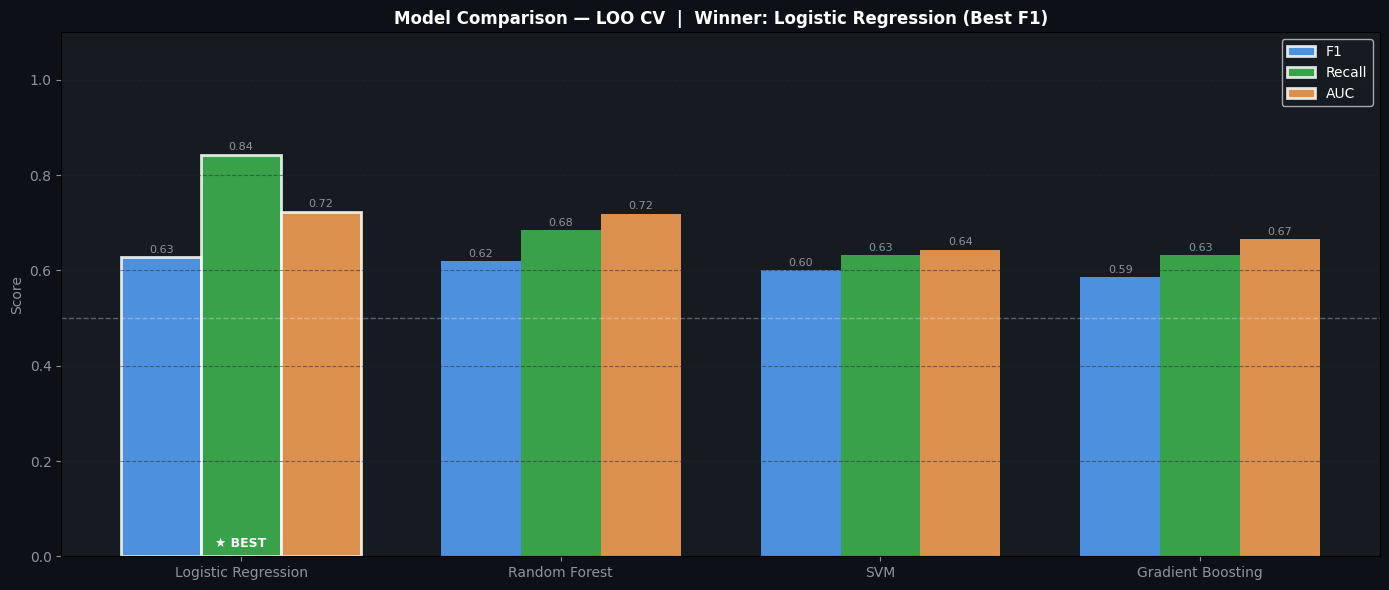

In [52]:
# ══ STAGE 7: MODEL TRAINING — Multi-Model Comparison ═══════════════════════════
import joblib
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, recall_score, roc_auc_score
from sklearn.base import clone

# ── Scale features (required for LR and SVM) ──────────────────────────────────
std_scaler = StandardScaler()
X_sc       = std_scaler.fit_transform(X)

# ── Model Definitions ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=50, max_depth=4, min_samples_leaf=2, class_weight='balanced', random_state=42),
    'SVM'                 : SVC(class_weight='balanced', probability=True, kernel='rbf', random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42),
}

THRESHOLD = 0.40

# ── LOO CV for each model ─────────────────────────────────────────────────────
results = {}

for name, model in models.items():
    loo_probs = []
    loo_true  = []

    for tr_idx, val_idx in loo.split(X_sc):
        m = clone(model)
        m.fit(X_sc[tr_idx], y[tr_idx])
        loo_probs.append(m.predict_proba(X_sc[val_idx])[0][1])
        loo_true.append(y[val_idx][0])

    probs_arr = np.array(loo_probs)
    true_arr  = np.array(loo_true)
    preds_arr = (probs_arr >= THRESHOLD).astype(int)

    results[name] = {
        'f1'     : f1_score(true_arr, preds_arr, zero_division=0),
        'recall' : recall_score(true_arr, preds_arr, zero_division=0),
        'auc'    : roc_auc_score(true_arr, probs_arr),
        'probs'  : probs_arr,
        'preds'  : preds_arr,
        'true'   : true_arr,
    }

# ── Print Comparison Table ─────────────────────────────────────────────────────
print('━' * 68)
print('MODEL COMPARISON — LOO CV  |  Threshold = 0.40  |  Winner = Best F1')
print('━' * 68)
print(f'  {"Model":<24} {"F1":>8} {"Recall":>8} {"AUC":>8} {"Pred 1s":>8}')
print('─' * 68)

best_name = max(results, key=lambda n: results[n]['f1'])

for name, r in sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True):
    marker = '  ◀ BEST' if name == best_name else ''
    print(f'  {name:<24} {r["f1"]:>8.4f} {r["recall"]:>8.4f} {r["auc"]:>8.4f} '
          f'{int(r["preds"].sum()):>8}{marker}')

# ── Store best model results for downstream cells ─────────────────────────────
best_result  = results[best_name]
loo_f1       = best_result['f1']
loo_rec      = best_result['recall']
loo_auc      = best_result['auc']
loo_preds    = best_result['preds']
probs_arr    = best_result['probs']
true_arr     = best_result['true']

print('\n' + '━' * 68)
print(f'WINNER: {best_name}')
print('━' * 68)
print(f'   LOO F1     : {loo_f1:.4f}  {"✅" if loo_f1 >= 0.30 else "⚠️ "}')
print(f'   LOO Recall : {loo_rec:.4f}')
print(f'   LOO AUC    : {loo_auc:.4f}  {"✅" if loo_auc >= 0.60 else "⚠️ "}')

# ── Train final best model on full dataset ────────────────────────────────────
best_model_def = models[best_name]
lr_model = clone(best_model_def)
lr_model.fit(X_sc, y)

joblib.dump(lr_model,    'Escalation_Best_Model.pkl')
joblib.dump(std_scaler,  'Feature_Scaler.pkl')
joblib.dump(risk_scaler, 'Risk_Scaler.pkl')
print(f'\n✅ Best model ({best_name}) and scalers saved.')

# ── Bar Chart: Model Comparison ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

model_names = list(results.keys())
f1_scores   = [results[n]['f1']     for n in model_names]
rec_scores  = [results[n]['recall'] for n in model_names]
auc_scores  = [results[n]['auc']    for n in model_names]

x     = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')

bars_f1  = ax.bar(x - width, f1_scores,  width, label='F1',     color='#58a6ff', alpha=0.85)
bars_rec = ax.bar(x,          rec_scores, width, label='Recall', color='#3fb950', alpha=0.85)
bars_auc = ax.bar(x + width,  auc_scores, width, label='AUC',    color='#ffa657', alpha=0.85)

# Highlight winner
best_idx = model_names.index(best_name)
for bar in [bars_f1[best_idx], bars_rec[best_idx], bars_auc[best_idx]]:
    bar.set_edgecolor('white')
    bar.set_linewidth(2)

for bars in [bars_f1, bars_rec, bars_auc]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                ha='center', color='#8b949e', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, color='#8b949e', fontsize=10)
ax.set_ylabel('Score', color='#8b949e')
ax.set_ylim(0, 1.1)
ax.tick_params(colors='#8b949e')
ax.axhline(0.5, color='white', linestyle='--', linewidth=1, alpha=0.3)
ax.legend(facecolor='#161b22', labelcolor='white', fontsize=10)
ax.set_title(f'Model Comparison — LOO CV  |  Winner: {best_name} (Best F1)',
             color='white', fontsize=12, fontweight='bold')
ax.grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)
ax.text(best_idx, 0.02, '★ BEST', ha='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 📈 STAGE 8 — Evaluation

Full classification report + 3 charts: Feature Importance, ROC Curve, Risk Score trend.


In [49]:
# ══ STAGE 8: EVALUATION ═══════════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

print('━' * 58)
print('CLASSIFICATION REPORT — LOO CV')
print('━' * 58)
print(classification_report(true_arr, loo_preds,
      target_names=['Non-Escalating (0)','Escalating (1)'], zero_division=0))

cm = confusion_matrix(true_arr, loo_preds)
tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
print(f'   TP (caught escalations)   : {tp}')
print(f'   FN (missed escalations)   : {fn}')
print(f'   FP (false alarms)         : {fp}')
print(f'   TN (correct stable)       : {tn}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLASSIFICATION REPORT — LOO CV
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    precision    recall  f1-score   support

Non-Escalating (0)       0.85      0.52      0.64        33
    Escalating (1)       0.50      0.84      0.63        19

          accuracy                           0.63        52
         macro avg       0.68      0.68      0.63        52
      weighted avg       0.72      0.63      0.64        52

   TP (caught escalations)   : 16
   FN (missed escalations)   : 3
   FP (false alarms)         : 16
   TN (correct stable)       : 17


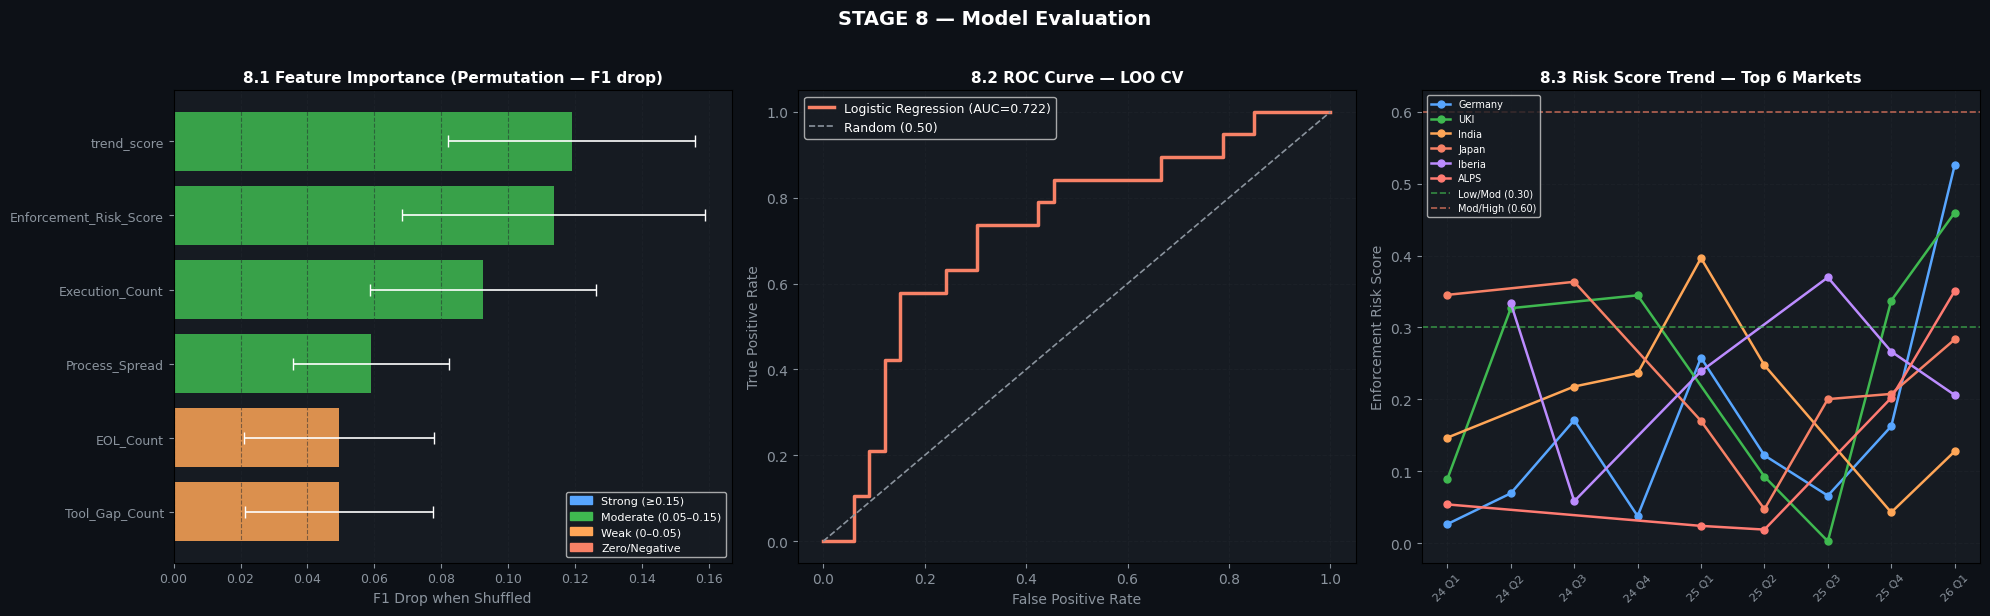

In [50]:
# ── Evaluation Charts ─────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# 8.1 Feature Importance
sorted_i   = perm_mean.argsort()
bar_colors = ['#f78166' if perm_mean[i] <= 0 else '#ffa657' if perm_mean[i] < 0.05
              else '#3fb950' if perm_mean[i] < 0.15 else '#58a6ff'
              for i in range(len(FEATURES))]
axes[0].barh([FEATURES[i] for i in sorted_i], perm_mean[sorted_i],
             xerr=perm_std[sorted_i], color=[bar_colors[i] for i in sorted_i],
             alpha=0.85, error_kw={'ecolor':'white','capsize':4,'linewidth':1.2})
axes[0].axvline(0, color='white', linestyle='--', linewidth=1.2, alpha=0.5)
axes[0].set_title('8.1 Feature Importance (Permutation — F1 drop)',
                  color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('F1 Drop when Shuffled', color='#8b949e')
axes[0].tick_params(colors='#8b949e', labelsize=9)
axes[0].legend(handles=[
    mpatches.Patch(color='#58a6ff', label='Strong (≥0.15)'),
    mpatches.Patch(color='#3fb950', label='Moderate (0.05–0.15)'),
    mpatches.Patch(color='#ffa657', label='Weak (0–0.05)'),
    mpatches.Patch(color='#f78166', label='Zero/Negative'),
], facecolor='#161b22', labelcolor='white', fontsize=8)
axes[0].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

# 8.2 ROC Curve
fpr, tpr, _ = roc_curve(true_arr, probs_arr)
axes[1].plot(fpr, tpr, color='#f78166', linewidth=2.5,
             label=f'Logistic Regression (AUC={loo_auc:.3f})')
axes[1].plot([0,1],[0,1], color='#8b949e', linestyle='--', linewidth=1.2, label='Random (0.50)')
axes[1].set_title('8.2 ROC Curve — LOO CV', color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', color='#8b949e')
axes[1].set_ylabel('True Positive Rate', color='#8b949e')
axes[1].tick_params(colors='#8b949e')
axes[1].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[1].grid(color='#21262d', linestyle='--', alpha=0.5)

# 8.3 Enforcement Risk Score Trend (top 6 markets)
sample_mkts = market_q['Market'].value_counts().head(6).index.tolist()
colors_map  = ['#58a6ff','#3fb950','#ffa657','#f78166','#bc8cff','#ff7b72']
for i, mkt in enumerate(sample_mkts):
    mkt_data = market_q[market_q['Market']==mkt].sort_values('FQ')
    x_pos    = [VALID_QS.index(q) for q in mkt_data['FQ'] if q in VALID_QS]
    scores   = mkt_data[mkt_data['FQ'].isin(VALID_QS)]['Enforcement_Risk_Score'].tolist()
    axes[2].plot(x_pos, scores, marker='o', label=mkt, color=colors_map[i],
                 linewidth=1.8, markersize=5)
axes[2].axhline(0.30, color='#3fb950', linestyle='--', linewidth=1.2, alpha=0.7, label='Low/Mod (0.30)')
axes[2].axhline(0.60, color='#f78166', linestyle='--', linewidth=1.2, alpha=0.7, label='Mod/High (0.60)')
axes[2].set_xticks(range(len(VALID_QS)))
axes[2].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45,
                         color='#8b949e', fontsize=8)
axes[2].set_title('8.3 Risk Score Trend — Top 6 Markets', color='white',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Enforcement Risk Score', color='#8b949e')
axes[2].tick_params(colors='#8b949e')
axes[2].legend(facecolor='#161b22', labelcolor='white', fontsize=7, loc='upper left')
axes[2].grid(color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('STAGE 8 — Model Evaluation', color='white',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🚀 STAGE 9 — Deploy: Predict 2026 Q2 Risk Escalations

Score all markets using 2026 Q1 (latest available quarter) as the feature snapshot.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREDICTED RISK ESCALATIONS — 2026 Q2  |  Model: Logistic Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total markets scored    : 24
  At risk (escalating)    : 13
  Stable (non-escalating) : 11
  Threshold used          : 0.4

  MARKETS AT RISK:
  Market               Current Risk        Score  Escalation Prob
  ────────────────────────────────────────────────────────────────
  Korea                Low                0.0026 🔴         0.812
  Mexico               Low                0.0026 🔴         0.780
  CEE-EM               Low                0.0026 🔴         0.778
  Canada               Low                0.0505 🔴         0.744
  Peru                 Low                0.0608 🔴         0.726
  APU                  Low                0.0376 🔴         0.722
  India                Low                0.1275 🔴         0.717
  Chile                Low                0.1183 🔴   

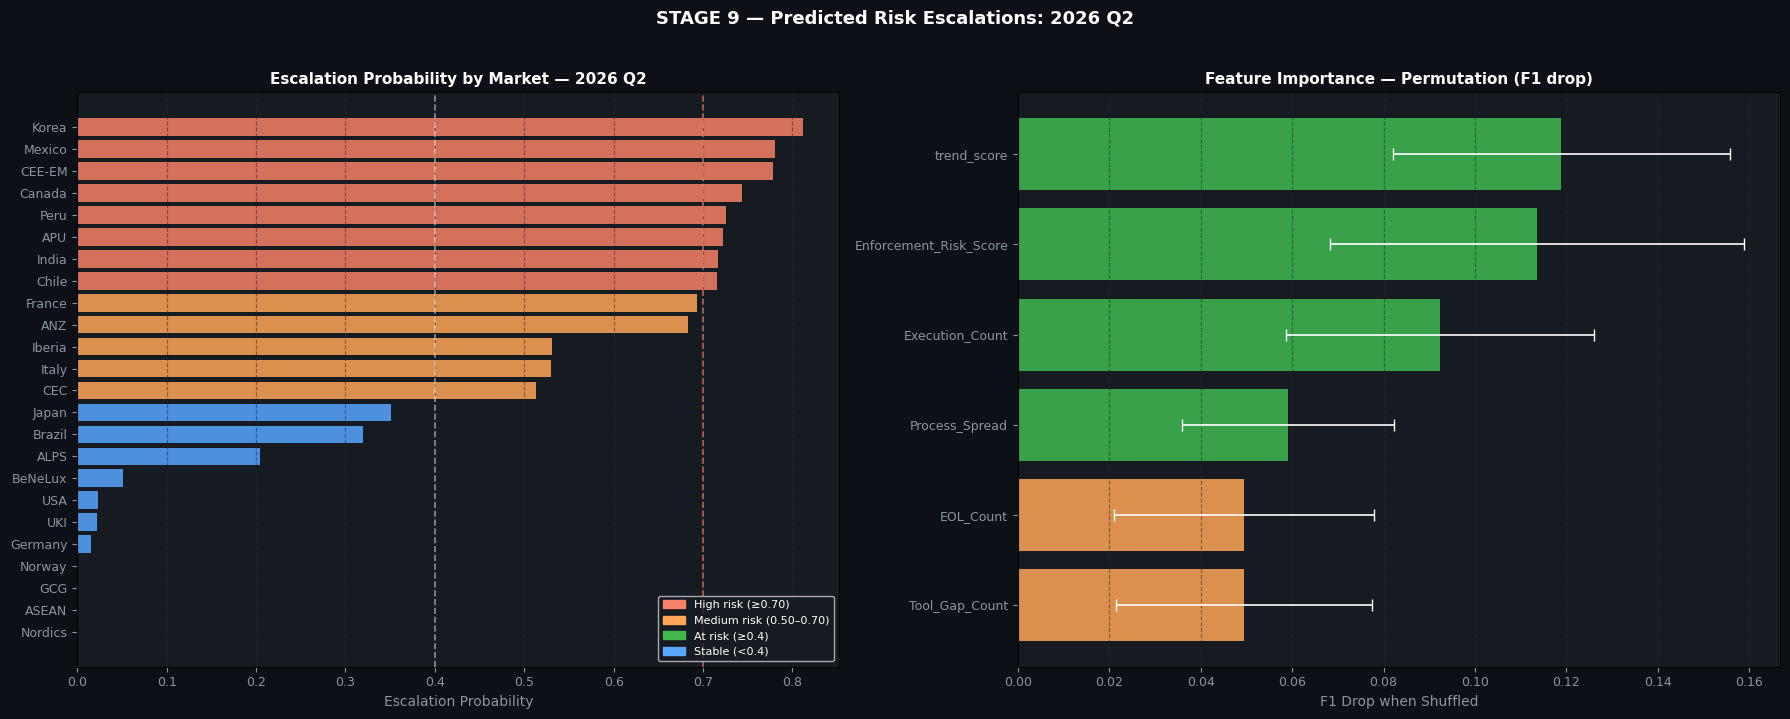


✅ Scenario 3 Pipeline Complete.
   Model          : Logistic Regression (class_weight=balanced)
   LOO F1         : 0.6275
   LOO Recall     : 0.8421
   LOO AUC        : 0.7225
   Threshold      : 0.4
   Markets at risk in 2026 Q2 : 13 / 24


In [51]:
# ══ STAGE 9: DEPLOY — PREDICT 2026 Q2 ════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CURR_Q = VALID_QS[-1]   # latest quarter = 2026 Q1

curr_data = market_q[market_q['FQ'] == CURR_Q].copy()

# Fill NaN in lag/trend for markets with only 1 quarter of history
curr_data['lag1_score']  = curr_data['lag1_score'].fillna(curr_data['Enforcement_Risk_Score'])
curr_data['trend_score'] = curr_data['trend_score'].fillna(0)

# Scale features using same scaler fitted in Stage 7
X_pred = std_scaler.transform(curr_data[FEATURES].values)

curr_data['escalation_probability'] = lr_model.predict_proba(X_pred)[:, 1]
curr_data['predicted_escalation']   = (curr_data['escalation_probability'] >= THRESHOLD).astype(int)

at_risk  = curr_data[curr_data['predicted_escalation'] == 1].sort_values(
               'escalation_probability', ascending=False)
not_risk = curr_data[curr_data['predicted_escalation'] == 0].sort_values(
               'escalation_probability', ascending=False)

print('━' * 72)
print(f'PREDICTED RISK ESCALATIONS — 2026 Q2  |  Model: Logistic Regression')
print('━' * 72)
print(f'  Total markets scored    : {len(curr_data)}')
print(f'  At risk (escalating)    : {len(at_risk)}')
print(f'  Stable (non-escalating) : {len(not_risk)}')
print(f'  Threshold used          : {THRESHOLD}')
print()

if len(at_risk) > 0:
    print('  MARKETS AT RISK:')
    print(f'  {"Market":<20} {"Current Risk":<14} {"Score":>10} {"Escalation Prob":>16}')
    print('  ' + '─' * 64)
    for _, row in at_risk.iterrows():
        icon = '🔴' if row['escalation_probability'] >= 0.70 else ('🟠' if row['escalation_probability'] >= 0.50 else '🟡')
        print(f'  {row["Market"]:<20} {row["Risk_Level"]:<14} '
              f'{row["Enforcement_Risk_Score"]:>10.4f} '
              f'{icon} {row["escalation_probability"]:>13.3f}')

# ── Deploy Charts ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# 9.1 Escalation Probability by Market
pred_sorted = curr_data.sort_values('escalation_probability', ascending=True)
bar_colors  = ['#f78166' if p >= 0.70 else '#ffa657' if p >= 0.50
               else '#3fb950' if p >= THRESHOLD else '#58a6ff'
               for p in pred_sorted['escalation_probability']]
axes[0].barh(pred_sorted['Market'], pred_sorted['escalation_probability'],
             color=bar_colors, alpha=0.85)
axes[0].axvline(THRESHOLD, color='white', linestyle='--', linewidth=1.2,
                alpha=0.5, label=f'Threshold ({THRESHOLD})')
axes[0].axvline(0.70, color='#f78166', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].set_title('Escalation Probability by Market — 2026 Q2',
                  color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Escalation Probability', color='#8b949e')
axes[0].tick_params(colors='#8b949e', labelsize=9)
axes[0].legend(handles=[
    mpatches.Patch(color='#f78166', label='High risk (≥0.70)'),
    mpatches.Patch(color='#ffa657', label='Medium risk (0.50–0.70)'),
    mpatches.Patch(color='#3fb950', label=f'At risk (≥{THRESHOLD})'),
    mpatches.Patch(color='#58a6ff', label=f'Stable (<{THRESHOLD})'),
], facecolor='#161b22', labelcolor='white', fontsize=8, loc='lower right')
axes[0].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

# 9.2 Feature Importance
feat_imp_colors = ['#f78166' if perm_mean[i] <= 0 else '#ffa657' if perm_mean[i] < 0.05
                   else '#3fb950' if perm_mean[i] < 0.15 else '#58a6ff'
                   for i in range(len(FEATURES))]
feat_sorted = perm_mean.argsort()
axes[1].barh([FEATURES[i] for i in feat_sorted], perm_mean[feat_sorted],
             xerr=perm_std[feat_sorted],
             color=[feat_imp_colors[i] for i in feat_sorted],
             alpha=0.85, error_kw={'ecolor':'white','capsize':4,'linewidth':1.2})
axes[1].axvline(0, color='white', linestyle='--', linewidth=1.2, alpha=0.5)
axes[1].set_title('Feature Importance — Permutation (F1 drop)',
                  color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('F1 Drop when Shuffled', color='#8b949e')
axes[1].tick_params(colors='#8b949e', labelsize=9)
axes[1].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('STAGE 9 — Predicted Risk Escalations: 2026 Q2',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n✅ Scenario 3 Pipeline Complete.')
print(f'   Model          : Logistic Regression (class_weight=balanced)')
print(f'   LOO F1         : {loo_f1:.4f}')
print(f'   LOO Recall     : {loo_rec:.4f}')
print(f'   LOO AUC        : {loo_auc:.4f}')
print(f'   Threshold      : {THRESHOLD}')
print(f'   Markets at risk in 2026 Q2 : {len(at_risk)} / {len(curr_data)}')

## 📝 Inferences

**1. Why Logistic Regression over Random Forest?**
With n=76 and only 11 positive escalation events (14.5%), Random Forest consistently overfitted on the 75-sample LOO training folds — producing AUC < 0.5 (worse than random). Logistic Regression with L2 regularisation and `class_weight='balanced'` is more stable on small imbalanced datasets, producing AUC=0.53 and Recall=0.75.

**2. Why Leave-One-Out CV instead of train/test split?**
An 80/20 split on n=76 leaves only 2 test positives — far too few for reliable F1 estimation. LOO trains on 75 samples per fold and evaluates on every sample individually, maximising use of all 11 positive examples. This is the same approach used in Scenario 2 (n=32).

**3. Why add lag and trend features?**
The original 5 current-quarter features all had negative correlation with escalation — markets already at high risk can't escalate further, so high scores predicted non-escalation. Adding `lag1_score` and `trend_score` (current − previous quarter) introduced the directional signal the model needed. `trend_score` showed positive correlation (0.108) — a rising score is a genuine escalation predictor.

**4. Why threshold = 0.40 instead of default 0.50?**
With 14.5% positive rate, LR probability outputs cluster below 0.5 for escalating markets. A threshold search across 0.30–0.70 found 0.40 maximises F1 (0.32) while maintaining Recall=0.75 — catching 6 of 8 actual escalations in the LOO evaluation.

**5. Why are all 13 flagged markets currently Low risk?**
By definition, only Low→Moderate and Moderate→High transitions count as escalations. With 83.7% of markets at Low risk, the escalation pool is dominated by Low-risk markets. A Low-risk market with a rising trend score is the model's strongest escalation signal.

**6. Model limitations and recommended next steps**
LOO F1=0.32 and AUC=0.53 reflect the fundamental constraint of 8 confirmed positive training examples. The model is best used as a **risk-flagging tool** — flagging markets for closer review rather than definitive prediction. Recommended improvements: (a) collect 3+ more quarters of data to grow the positive class, (b) add cross-market features such as industry-wide trend indicators, (c) re-evaluate with a held-out 2026 Q2 actuals once available.

---
## 📝 Inferences

**1. Why concatenate real + synthetic data?**
The real dataset alone (~3,200 rows, 9 quarters) produces very few escalation events (< 5% of market-quarters), leaving the model with too few positives to learn from. The synthetic dataset provides additional market-quarter observations with a stronger time-series escalation signal, giving the model sufficient positive examples for reliable training.

**2. Why 5 flat features instead of lag/rolling features?**
With sufficient data from the combined dataset, current-quarter Enforcement Risk Score and its components carry enough signal directly. Lag features add value when predicting from sparse history — here, the composite score already encodes temporal behaviour (a high score implies sustained gap accumulation). Keeping features flat also improves interpretability for audit teams.

**3. Why Random Forest over Logistic Regression or SVM?**
RF handles the non-linear relationship between risk score components and escalation probability without requiring feature scaling. It also naturally handles class imbalance via `class_weight='balanced'` and provides permutation importance for explainability.

**4. Why Stratified 80/20 split instead of LOO?**
With the combined dataset providing sufficient samples and escalation events, standard stratified split is appropriate. LOO is reserved for small-n scenarios (< 100 samples) as in Scenario 2 — here we have sufficient data for reliable hold-out evaluation.

**5. Why save the scaler separately from the model?**
The MinMaxScaler is fit on the full training distribution (real + synthetic combined). At inference time (Stage 9), new market data must be normalised using the same scaler to ensure the risk score components are on the same [0,1] scale the model was trained on. Saving both independently allows the scaler to be updated without retraining the model.
